In [1]:
import torch
from torch import nn
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np
import time

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [2]:
train_data_full = datasets.FashionMNIST(
    root="data",           # where to store the download
    train=True,            # the 60k training split
    download=True,
    transform=transforms.ToTensor(),   # PIL image -> float tensor in [0, 1]
)
test_data_full = datasets.FashionMNIST(
    root="data",
    train=False,           # the 10k test split
    download=True,
    transform=transforms.ToTensor(),
)

len(train_data_full), len(test_data_full)

(60000, 10000)

In [3]:
torch.manual_seed(42)          # same subset every rerun

N_TRAIN_SUBSET = 6000          # ~10% of the training set
N_TEST_SUBSET = 2000           # ~20% of the test set

train_data = Subset(train_data_full, torch.randperm(len(train_data_full))[:N_TRAIN_SUBSET])
test_data = Subset(test_data_full, torch.randperm(len(test_data_full))[:N_TEST_SUBSET])

class_names = train_data_full.classes          # 10 labels, strings like "Ankle boot"
len(train_data), len(test_data), class_names

(6000, 2000, ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'])

In [4]:
BATCH_SIZE = 32

train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

# "iterate the dataloader" = this exact pattern, everywhere below
X_train_batch, y_train_batch = next(iter(train_dataloader))
X_train_batch.shape, y_train_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

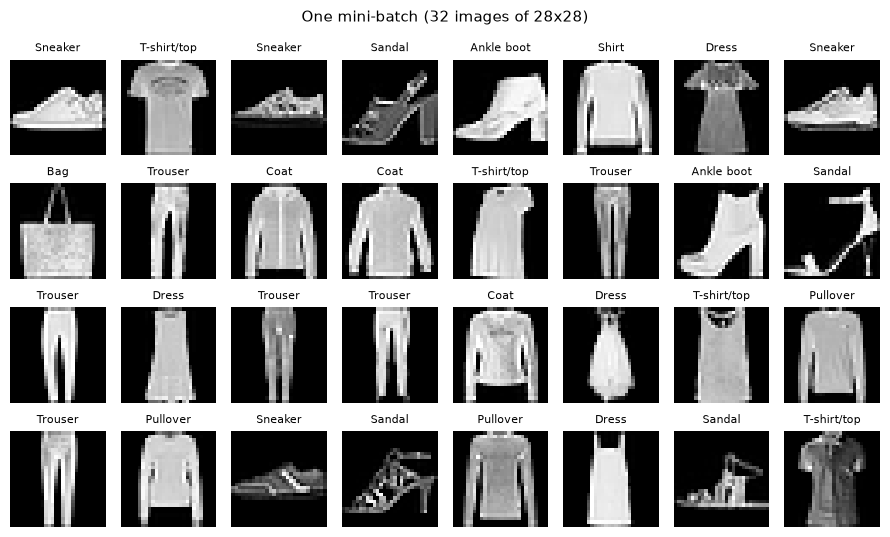

In [5]:
# what a shuffled mini-batch of images looks like
fig, axes = plt.subplots(4, 8, figsize=(9, 5.5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_batch[i].squeeze(), cmap="gray")
    ax.set_title(class_names[y_train_batch[i]], fontsize=8)
    ax.axis("off")
plt.suptitle("One mini-batch (32 images of 28x28)", fontsize=11)
plt.tight_layout()
plt.show()

In [6]:
torch.manual_seed(42)

class FashionBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.stack = nn.Sequential(
            nn.Flatten(),                      # [B, 1, 28, 28] -> [B, 784]
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 10),                # 10 = one logit per class
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.stack(x)

model_baseline = FashionBaseline().to(device)
model_baseline

FashionBaseline(
  (stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [7]:
loss_fn = nn.CrossEntropyLoss()   # raw logits in, no softmax needed before it

def accuracy_fn(y_true, y_pred):
    """Fraction correct, as a percentage."""
    correct = torch.eq(y_true, y_pred).sum().item()
    return correct / len(y_true) * 100

In [8]:
torch.manual_seed(42)
model_baseline = FashionBaseline().to(device)
optimizer = torch.optim.Adam(params=model_baseline.parameters(), lr=0.001)

epochs = 5
t0 = time.time()

for epoch in range(epochs):
    epoch_t0 = time.time()
    model_baseline.train()

    # ---- 5-step loop, per mini-batch instead of once per epoch ----
    for X_batch, y_batch in train_dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model_baseline(X_batch)                # 1. forward pass
        loss = loss_fn(logits, y_batch)                 # 2. compute loss (on logits)
        optimizer.zero_grad()                           # 3. reset old gradients
        loss.backward()                                 # 4. backpropagation
        optimizer.step()                                # 5. gradient descent step

    # ---- end-of-epoch metrics (no gradients needed) ----
    model_baseline.eval()
    train_loss, train_acc = 0.0, 0.0
    with torch.inference_mode():
        for X_batch, y_batch in train_dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model_baseline(X_batch)
            train_loss += loss_fn(logits, y_batch).item() * len(X_batch)
            train_acc += accuracy_fn(y_batch, logits.argmax(dim=1)) * len(X_batch) / 100
    train_loss /= N_TRAIN_SUBSET
    train_acc /= N_TRAIN_SUBSET / 100

    test_loss, test_acc = 0.0, 0.0
    with torch.inference_mode():
        for X_batch, y_batch in test_dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model_baseline(X_batch)
            test_loss += loss_fn(logits, y_batch).item() * len(X_batch)
            test_acc += accuracy_fn(y_batch, logits.argmax(dim=1)) * len(X_batch) / 100
    test_loss /= N_TEST_SUBSET
    test_acc /= N_TEST_SUBSET / 100

    print(
        f"epoch: {epoch} | "
        f"train loss: {train_loss:.4f}, acc: {train_acc:.2f}% | "
        f"test loss: {test_loss:.4f}, acc: {test_acc:.2f}% | "
        f"time: {time.time() - epoch_t0:.2f}s"
    )

print(f"\ntotal training time: {time.time() - t0:.2f}s")

epoch: 0 | train loss: 0.6145, acc: 77.62% | test loss: 0.6018, acc: 78.20% | time: 1.28s
epoch: 1 | train loss: 0.5093, acc: 81.88% | test loss: 0.5141, acc: 81.05% | time: 1.25s
epoch: 2 | train loss: 0.4873, acc: 82.68% | test loss: 0.5066, acc: 81.00% | time: 1.24s
epoch: 3 | train loss: 0.4382, acc: 83.68% | test loss: 0.4838, acc: 81.35% | time: 1.25s
epoch: 4 | train loss: 0.3999, acc: 85.77% | test loss: 0.4503, acc: 83.90% | time: 1.28s

total training time: 6.30s


In [9]:
def eval_model(model):
    """Overall + per-class accuracy on the test set."""
    model.eval()
    counts = torch.zeros(len(class_names), dtype=torch.long)
    correct = torch.zeros(len(class_names), dtype=torch.long)
    test_loss, n_total, test_acc = 0.0, 0, 0.0
    with torch.inference_mode():
        for X_batch, y_batch in test_dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            test_loss += loss_fn(logits, y_batch).item() * len(X_batch)
            preds = logits.argmax(dim=1)
            for p, t in zip(preds.tolist(), y_batch.tolist()):
                counts[t] += 1
                correct[t] += int(p == t)
            test_acc += accuracy_fn(y_batch, preds) * len(X_batch)
            n_total += len(X_batch)
    return (
        test_loss / n_total,
        test_acc / n_total,
        (100.0 * correct / counts.float()).tolist(),
    )

_, baseline_test_acc, baseline_perclass = eval_model(model_baseline)
print(f"baseline test acc: {baseline_test_acc:.2f}%")
for c, a in zip(class_names, baseline_perclass):
    print(f"  {c:<15} {a:.1f}%")

baseline test acc: 83.90%
  T-shirt/top     87.4%
  Trouser         90.7%
  Pullover        76.5%
  Dress           84.1%
  Coat            71.4%
  Sandal          88.3%
  Shirt           54.3%
  Sneaker         92.2%
  Bag             95.5%
  Ankle boot      96.7%


In [10]:
torch.manual_seed(42)

class FashionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(            # 28x28 -> 7x7 feature maps
            nn.Conv2d(1, 8, kernel_size=3, padding=1),   # [B, 1, 28, 28] -> [B, 8, 28, 28]
            nn.ReLU(),
            nn.MaxPool2d(2),                             # [B, 8, 28, 28] -> [B, 8, 14, 14]
            nn.Conv2d(8, 16, kernel_size=3, padding=1),  # [B, 8, 14, 14] -> [B, 16, 14, 14]
            nn.ReLU(),
            nn.MaxPool2d(2),                             # [B, 16, 14, 14] -> [B, 16, 7, 7]
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                                # [B, 16, 7, 7] -> [B, 784]
            nn.Linear(784, 32),
            nn.ReLU(),
            nn.Linear(32, 10),                           # [B, 784] -> [B, 10]
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))

model_cnn = FashionCNN().to(device)
model_cnn

FashionCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=10, bias=True)
  )
)

In [11]:
torch.manual_seed(42)
model_cnn = FashionCNN().to(device)
optimizer = torch.optim.Adam(params=model_cnn.parameters(), lr=0.001)

epochs = 8
t0 = time.time()

for epoch in range(epochs):
    epoch_t0 = time.time()
    model_cnn.train()

    for X_batch, y_batch in train_dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model_cnn(X_batch)                     # 1. forward pass
        loss = loss_fn(logits, y_batch)                 # 2. compute loss (on logits)
        optimizer.zero_grad()                           # 3. reset old gradients
        loss.backward()                                 # 4. backpropagation
        optimizer.step()                                # 5. gradient descent step

    model_cnn.eval()
    train_loss, train_acc = 0.0, 0.0
    with torch.inference_mode():
        for X_batch, y_batch in train_dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model_cnn(X_batch)
            train_loss += loss_fn(logits, y_batch).item() * len(X_batch)
            train_acc += accuracy_fn(y_batch, logits.argmax(dim=1)) * len(X_batch) / 100
    train_loss /= N_TRAIN_SUBSET
    train_acc /= N_TRAIN_SUBSET / 100

    test_loss, test_acc = 0.0, 0.0
    with torch.inference_mode():
        for X_batch, y_batch in test_dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model_cnn(X_batch)
            test_loss += loss_fn(logits, y_batch).item() * len(X_batch)
            test_acc += accuracy_fn(y_batch, logits.argmax(dim=1)) * len(X_batch) / 100
    test_loss /= N_TEST_SUBSET
    test_acc /= N_TEST_SUBSET / 100

    print(
        f"epoch: {epoch} | "
        f"train loss: {train_loss:.4f}, acc: {train_acc:.2f}% | "
        f"test loss: {test_loss:.4f}, acc: {test_acc:.2f}% | "
        f"time: {time.time() - epoch_t0:.2f}s"
    )

print(f"\ntotal training time: {time.time() - t0:.2f}s")

epoch: 0 | train loss: 0.7661, acc: 70.30% | test loss: 0.7281, acc: 73.05% | time: 2.76s
epoch: 1 | train loss: 0.6452, acc: 75.02% | test loss: 0.6210, acc: 76.10% | time: 2.78s
epoch: 2 | train loss: 0.5530, acc: 79.87% | test loss: 0.5441, acc: 79.45% | time: 2.86s
epoch: 3 | train loss: 0.5295, acc: 80.30% | test loss: 0.5166, acc: 80.65% | time: 2.91s
epoch: 4 | train loss: 0.4381, acc: 83.50% | test loss: 0.4480, acc: 83.15% | time: 2.94s
epoch: 5 | train loss: 0.4232, acc: 84.33% | test loss: 0.4297, acc: 83.50% | time: 2.88s
epoch: 6 | train loss: 0.4010, acc: 85.23% | test loss: 0.4140, acc: 85.50% | time: 2.79s
epoch: 7 | train loss: 0.3792, acc: 86.52% | test loss: 0.3970, acc: 84.95% | time: 2.77s

total training time: 22.70s


In [12]:
_, cnn_test_acc, cnn_perclass = eval_model(model_cnn)
print(f"CNN test acc: {cnn_test_acc:.2f}%")
for c, a in zip(class_names, cnn_perclass):
    print(f"  {c:<15} {a:.1f}%")

CNN test acc: 84.95%
  T-shirt/top     67.2%
  Trouser         92.0%
  Pullover        69.0%
  Dress           88.7%
  Coat            75.4%
  Sandal          97.6%
  Shirt           69.8%
  Sneaker         93.7%
  Bag             97.0%
  Ankle boot      93.8%


baseline: 83.90%  ->  CNN: 84.95%


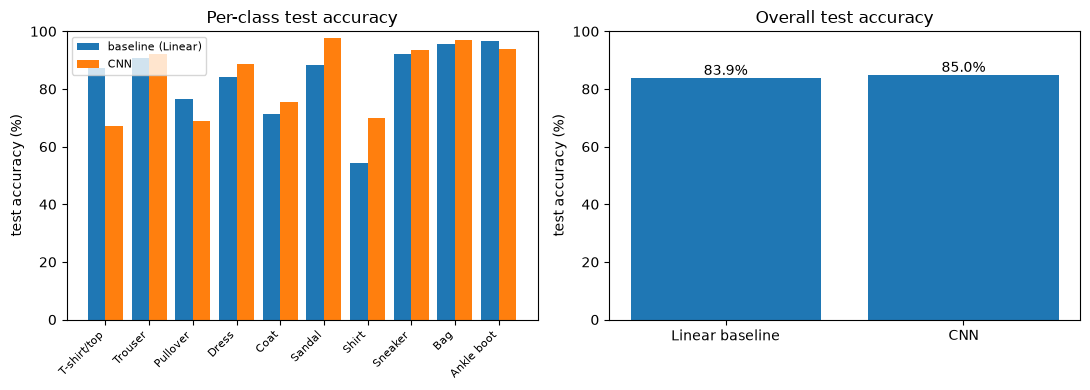

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(len(class_names))
axes[0].bar(x - 0.2, baseline_perclass, width=0.4, label="baseline (Linear)")
axes[0].bar(x + 0.2, cnn_perclass, width=0.4, label="CNN")
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_names, rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("test accuracy (%)")
axes[0].set_ylim(0, 100)
axes[0].set_title("Per-class test accuracy")
axes[0].legend(fontsize=8)

axes[1].bar(["Linear baseline", "CNN"], [baseline_test_acc, cnn_test_acc])
axes[1].set_ylim(0, 100)
axes[1].set_ylabel("test accuracy (%)")
for i, v in enumerate([baseline_test_acc, cnn_test_acc]):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10)
axes[1].set_title("Overall test accuracy")
plt.tight_layout()
plt.show()

print(f"baseline: {baseline_test_acc:.2f}%  ->  CNN: {cnn_test_acc:.2f}%")

same 9 weights slid over the whole image is all a conv layer does - times 8 filters (then 16)


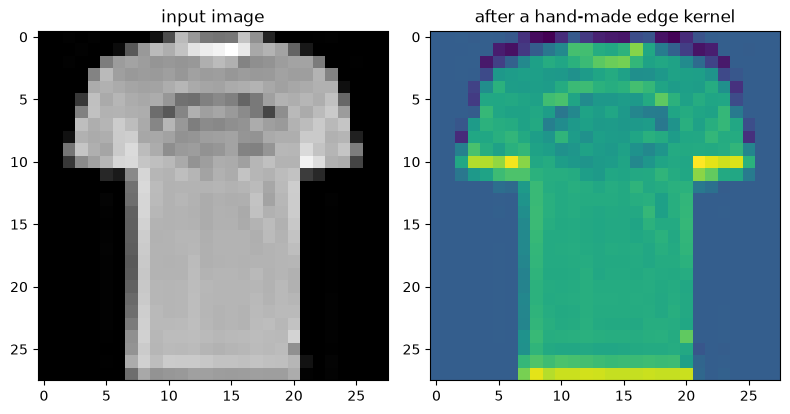

In [14]:
# a tiny hand-crafted "kernel": a vertical-edge detector
edge_kernel = torch.tensor([[0, 1, 0],
                            [0, 1, 0],
                            [0, -1, 0]], dtype=torch.float32).unsqueeze(0).unsqueeze(0)

# put it at one position, then move it: same weights, same feature fires anywhere
img = X_train_batch[1].unsqueeze(0)  # a real FashionMNIST image
feature_map = torch.nn.functional.conv2d(img, edge_kernel, padding=1)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img.squeeze(), cmap="gray")
axes[0].set_title("input image")
axes[1].imshow(feature_map.detach().squeeze(), cmap="viridis")
axes[1].set_title("after a hand-made edge kernel")
plt.tight_layout()
plt.show()

print("same 9 weights slid over the whole image is all a conv layer does - times 8 filters (then 16)")

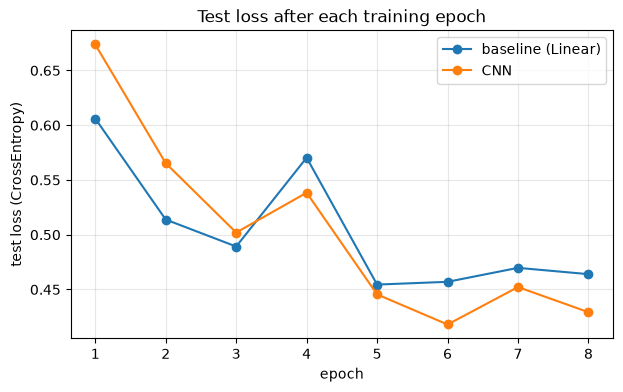

In [15]:
# re-run both trainings from scratch (8 epochs, same seeds), recording the test
# loss each epoch for the loss-curve plot below
def train_and_record(model, n_epochs=8):
    torch.manual_seed(42)
    opt = torch.optim.Adam(params=model.parameters(), lr=0.001)
    out = []
    for epoch in range(n_epochs):
        model.train()
        for X_batch, y_batch in train_dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)
            opt.zero_grad()
            loss.backward()
            opt.step()
        model.eval()
        tl = 0.0
        with torch.inference_mode():
            for X_batch, y_batch in test_dataloader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                tl += loss_fn(model(X_batch), y_batch).item() * len(X_batch)
        out.append(tl / N_TEST_SUBSET)
    return out

test_losses_for_plot = {}

def record(name, model):
    test_losses_for_plot[name] = train_and_record(model)

# fresh copies so we do not disturb the trained models above
def fresh_baseline():
    torch.manual_seed(42)
    return FashionBaseline().to(device)

def fresh_cnn():
    torch.manual_seed(42)
    return FashionCNN().to(device)

for name, make in [("baseline", fresh_baseline), ("cnn", fresh_cnn)]:
    record(name, make())

plt.figure(figsize=(7, 4))
plt.plot(range(1, 9), test_losses_for_plot["baseline"], marker="o", label="baseline (Linear)")
plt.plot(range(1, 9), test_losses_for_plot["cnn"], marker="o", label="CNN")
plt.xlabel("epoch")
plt.ylabel("test loss (CrossEntropy)")
plt.xticks(range(1, 9))
plt.title("Test loss after each training epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

biggest confusions (true -> predicted):
    41  T-shirt/top -> Shirt
    30  Pullover -> Shirt
    27  Coat -> Shirt
    24  Pullover -> Coat
    22  Shirt -> T-shirt/top


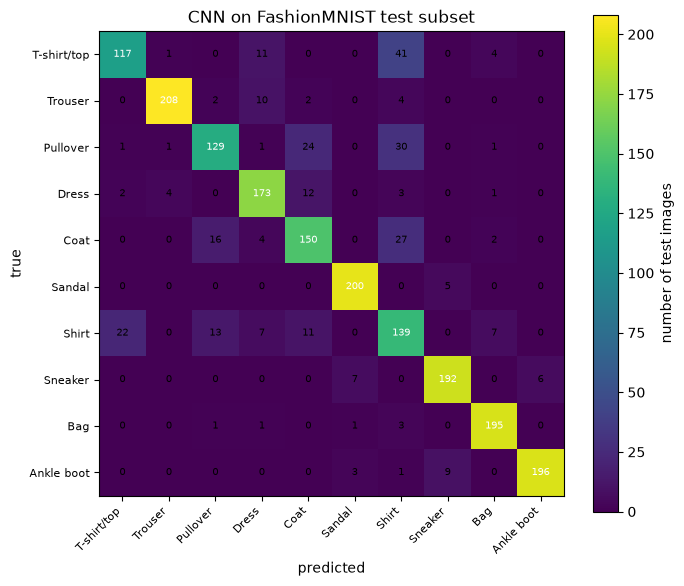

In [16]:
def confusion_matrix(model):
    mat = torch.zeros(len(class_names), len(class_names), dtype=torch.long)
    model.eval()
    with torch.inference_mode():
        for X_batch, y_batch in test_dataloader:
            preds = model(X_batch.to(device)).argmax(dim=1).cpu()
            for p, t in zip(preds.tolist(), y_batch.tolist()):
                mat[t, p] += 1
    return mat

conf_mat = confusion_matrix(model_cnn)

plt.figure(figsize=(7, 6))
plt.imshow(conf_mat.numpy(), cmap="viridis")
plt.colorbar(label="number of test images")
plt.xticks(range(10), class_names, rotation=45, ha="right", fontsize=8)
plt.yticks(range(10), class_names, fontsize=8)
for i in range(10):
    for j in range(10):
        val = conf_mat[i, j].item()
        plt.text(j, i, str(val), ha="center", va="center", fontsize=7,
                 color="white" if val > conf_mat.max().item() / 2 else "black")
plt.xlabel("predicted")
plt.ylabel("true")
plt.title("CNN on FashionMNIST test subset")
plt.tight_layout()
plt.show()

print("biggest confusions (true -> predicted):")
off_diag = [
    (conf_mat[i, j].item(), f"{class_names[i]} -> {class_names[j]}")
    for i in range(10) for j in range(10) if i != j
]
for count, pair in sorted(off_diag, reverse=True)[:5]:
    print(f"  {count:4d}  {pair}")

7 wrong out of 32 in this batch (22% error rate)


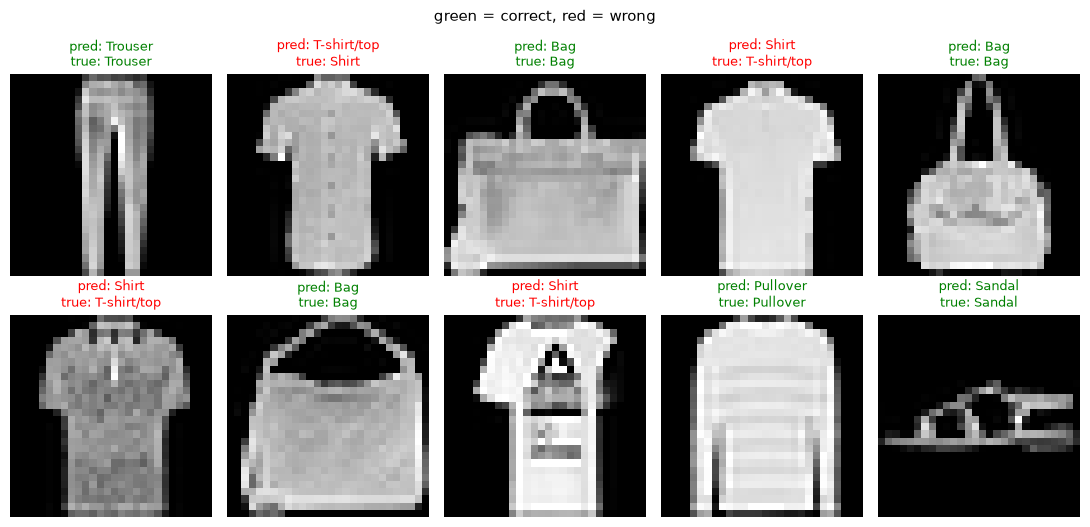

In [17]:
from torch.utils.data import DataLoader

torch.manual_seed(42)
model_cnn.eval()

X_test_batch, y_test_batch = next(iter(test_dataloader))
with torch.inference_mode():
    test_logits_cnn = model_cnn(X_test_batch.to(device))
    test_preds_cnn = test_logits_cnn.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(11, 5.5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test_batch[i].squeeze(), cmap="gray")
    true_l, pred_l = class_names[y_test_batch[i]], class_names[test_preds_cnn[i]]
    is_wrong = y_test_batch[i].item() != test_preds_cnn[i].item()
    color = "red" if is_wrong else "green"
    ax.set_title(f"pred: {pred_l}\ntrue: {true_l}", fontsize=9, color=color)
    ax.axis("off")
plt.suptitle("green = correct, red = wrong", fontsize=11)
plt.tight_layout()
plt.show()

n_wrong = (y_test_batch != test_preds_cnn).sum().item()
print(f"{n_wrong} wrong out of {len(y_test_batch)} in this batch ({100*n_wrong/len(y_test_batch):.0f}% error rate)")